In [1]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv('full_train_US-Ne1.csv')

In [3]:
df1 = df.drop(['Unnamed: 0'],axis=1).copy()

In [4]:
df1['TIMESTAMP_START']=pd.to_datetime(df1['TIMESTAMP_START'].astype(str), format='%Y%m%d%H%M')

In [5]:
df1['HOUR'] = df1['TIMESTAMP_START'].dt.hour
df1['MONTH']  = df1['TIMESTAMP_START'].dt.month
df1['DAY'] = df1['TIMESTAMP_START'].dt.day
df1['YEAR']  = df1['TIMESTAMP_START'].dt.year
df1['HOUR'] = df1['TIMESTAMP_START'].dt.hour
df1['MINUTE'] = df1['TIMESTAMP_START'].dt.minute
df1.drop(['TIMESTAMP_START'],axis=1,inplace=True)

In [6]:
def get_df_in_range(df, start_date, end_date):
    current_dates = df['YEAR'] * 10000 + df['MONTH'] * 100 + df['DAY']
    mask = (current_dates >= start_date) & (current_dates <= end_date)
    return df[mask]

df2 = get_df_in_range(df1, 20140101, 20221231)

In [9]:
# sel = [
#  'YEAR',
#  'MONTH',
#  'DAY',
#  'HOUR',
#  'MINUTE',
#  'TA',
#  'SW_IN',
#  'LW_IN',
#  'VPD',
#  'RH',
#  'TS',
#  'SWC',
#  'NDVI',
#  'LE',]

In [10]:
# df2[sel].head()

In [11]:
# import dataframe_image as dfi

# df_styled = df2[sel].head().reset_index(drop=True)

# # Use 'matplotlib' instead of the default 'chrome' or 'playwright'
# dfi.export(df_styled, 'dataframe_sample.png', table_conversion='matplotlib')

In [12]:
df2 = df2.reset_index(drop=True)

In [13]:
df2.shape

(68781, 16)

In [14]:
#3)
df2['LE_diff'] = df2['LE'].diff().abs()
threshold = 250
df2 = df2[df2['LE_diff'] < threshold]
df2 = df2.drop(columns=['LE_diff'])
df2.shape

(68636, 16)

In [15]:
df2.shape

(68636, 16)

# NIGHT TME

In [16]:
night_df = df2[(df2['HOUR']>20)|(df2['HOUR']<4)]

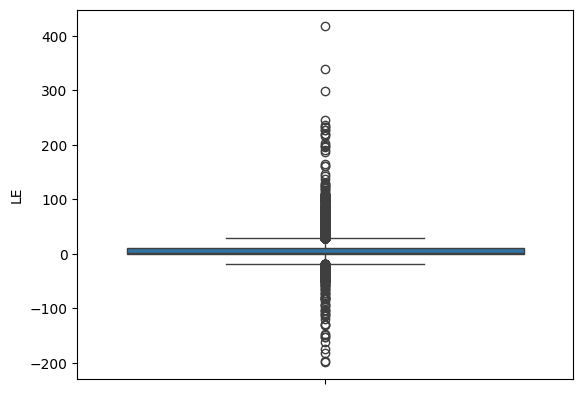

In [17]:
ax = sns.boxplot(night_df['LE'])
plt.savefig('Images/night_box_before.png')
plt.show()

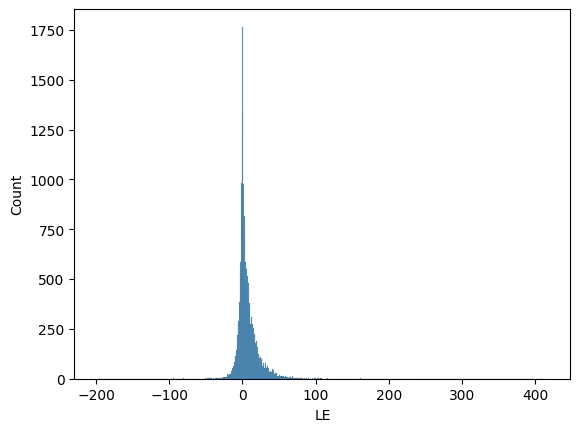

In [18]:
ax = sns.histplot(night_df['LE'])
plt.savefig('Images/night_hist_before.png')
plt.show()

In [19]:
col_remove = night_df[(night_df['LE']>60)|(night_df['LE']<-10)].index 
df2.drop(col_remove,inplace=True)

In [20]:
night_df = df2[(df2['HOUR']>20)|(df2['HOUR']<4)]

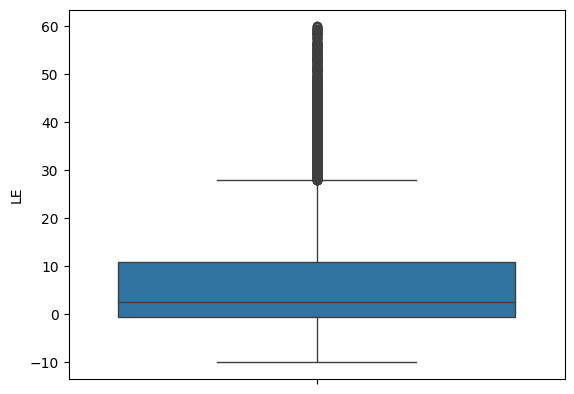

In [21]:
sns.boxplot(night_df['LE'])
plt.savefig('Images/night_box_after.png')
plt.show()

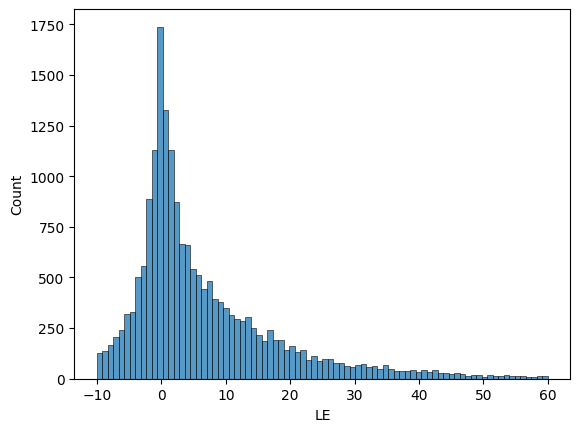

In [22]:
ax = sns.histplot(night_df['LE'])
plt.savefig('Images/night_hist_after.png')
plt.show()

# DAYTIME

In [23]:
day_df = df2[(df2['HOUR']<=20)|(df2['HOUR']>=4)]

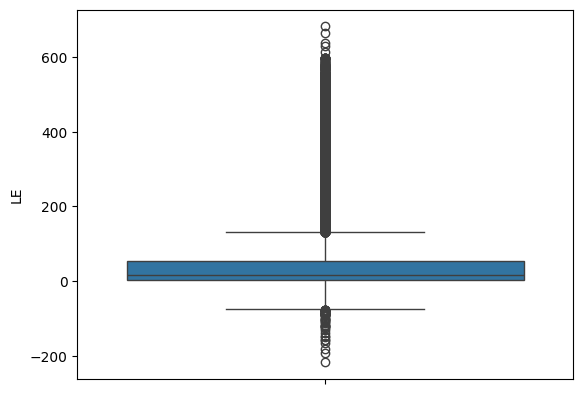

In [24]:
ax = sns.boxplot(day_df['LE'])
plt.savefig('Images/day_box_before.png')
plt.show()

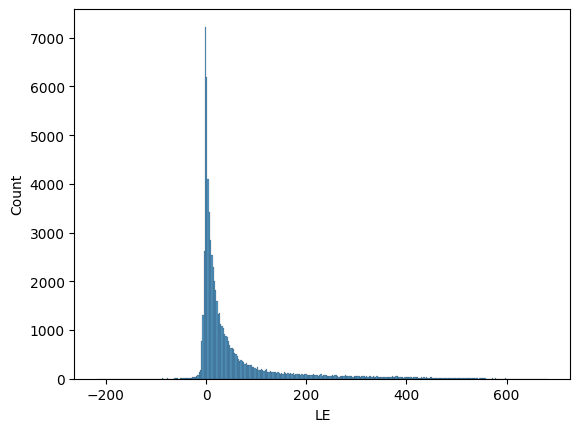

In [25]:
ax = sns.histplot(day_df['LE'])
plt.savefig('Images/day_hist_before.png')
plt.show()

In [26]:
col_remove = day_df[(day_df['LE']>550)|(day_df['LE']<-75)].index 
df2.drop(col_remove,inplace=True)

In [27]:
day_df = df2[(df2['HOUR']<=20)|(df2['HOUR']>=4)]

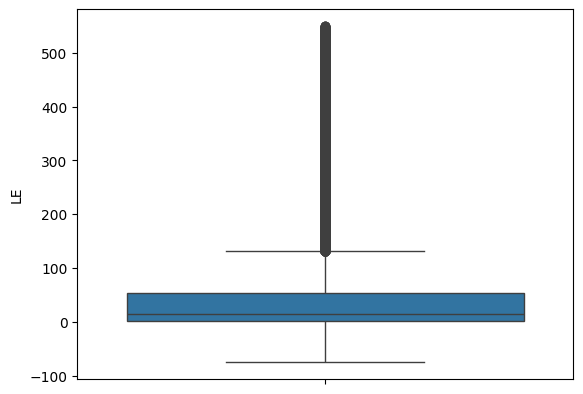

In [28]:
ax = sns.boxplot(day_df['LE'])
plt.savefig('Images/day_box_after.png')
plt.show()

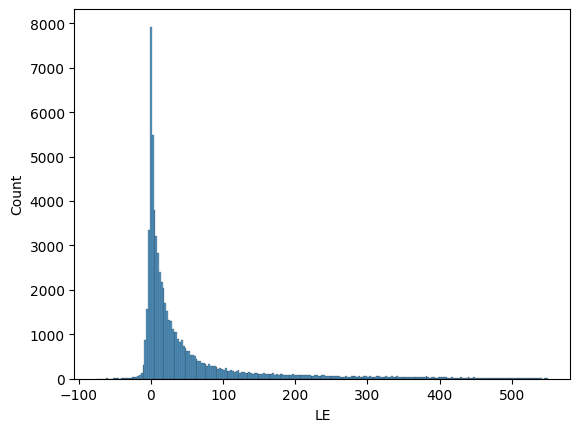

In [29]:
ax = sns.histplot(day_df['LE'])
plt.savefig('Images/day_hist_after.png')
plt.show()

In [30]:
df2

,TA,SW_IN,LW_IN,VPD,PA,P,RH,TS,SWC,LE,NDVI,HOUR,MONTH,DAY,YEAR,MINUTE
1,-12.80,0.0,247.4,0.434,97.98,0.000,81.0,-6.635,12.800,2.9,0.197025,1,1,1,2014,0
2,-12.93,0.0,240.9,0.429,98.04,0.000,81.0,-6.780,12.767,2.9,0.197025,2,1,1,2014,0
3,-12.90,0.0,236.9,0.441,98.06,0.000,80.5,-7.100,12.733,2.7,0.197025,3,1,1,2014,0
4,-12.38,0.0,251.0,0.520,98.08,0.002,78.0,-7.155,12.667,3.9,0.197025,4,1,1,2014,0
5,-12.38,0.0,255.0,0.520,98.10,0.019,78.0,-7.155,12.667,4.1,0.197025,5,1,1,2014,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68776,3.56,0.1,305.8,1.727,96.41,0.000,78.1,-0.375,17.033,-2.3,0.228910,19,12,31,2022,0
68777,3.20,0.0,304.7,1.638,96.49,0.000,78.7,-0.380,17.100,-1.1,0.228910,20,12,31,2022,0
68778,2.16,0.1,307.7,1.292,96.52,0.000,81.9,-0.390,17.100,0.0,0.228910,21,12,31,2022,0
68779,1.18,0.1,293.9,0.945,96.54,0.000,85.8,-0.400,17.133,2.2,0.228910,22,12,31,2022,0


In [31]:
df2.shape

(67569, 16)

In [32]:
start_date = "2016-04-01 00:00:00"
end_date   = "2016-10-29 23:59:59"

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
def plot_LE(df,start_date,end_date):
    df['timestamp'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE']])
    mask = (df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)
    filtered_df = df.loc[mask]
    plt.figure(figsize=(12, 6))
    plt.plot(filtered_df['timestamp'], filtered_df['LE'], color='teal', linewidth=1)
    plt.title(f'Hourly Latent Heat Flux (LE) from {start_date[0:10]} to {end_date[0:10]} of Corn', fontsize=14)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('LE', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Images/LE_plot_hourly.png')
    plt.show()

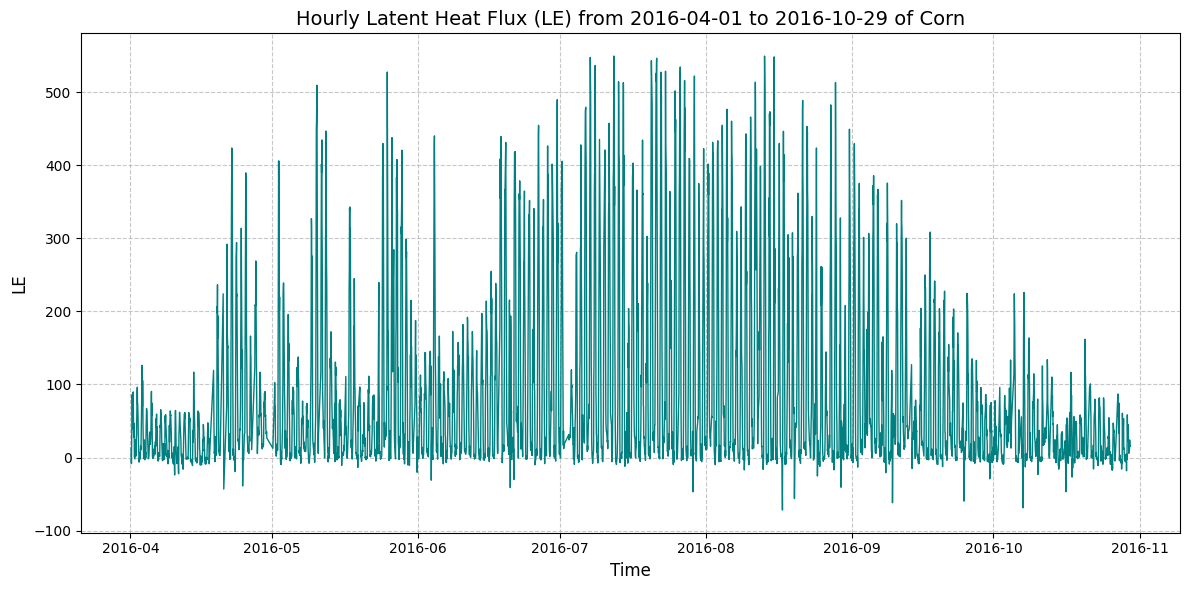

In [34]:
plot_LE(df2,start_date,end_date)

In [35]:
df2.groupby(['YEAR','MONTH','DAY']).mean()['LE']

YEAR  MONTH  DAY
2014  1      1       7.955556
             2       5.405263
             3      18.337500
             4      17.355000
             5      17.600000
                      ...    
2022  12     27     15.878261
             28      7.345833
             29      7.490909
             30      9.933333
             31      4.225000
Name: LE, Length: 3167, dtype: float64

In [36]:
daily_avg_df = df2.groupby(['YEAR', 'MONTH', 'DAY'])['LE'].mean().reset_index()
daily_avg_df

,YEAR,MONTH,DAY,LE
0,2014,1,1,7.955556
1,2014,1,2,5.405263
2,2014,1,3,18.337500
3,2014,1,4,17.355000
4,2014,1,5,17.600000
...,...,...,...,...
3162,2022,12,27,15.878261
3163,2022,12,28,7.345833
3164,2022,12,29,7.490909
3165,2022,12,30,9.933333


In [37]:
def plot_LE_daily(df,start_date,end_date):
    df['timestamp'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
    mask = (df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)
    filtered_df = df.loc[mask]
    plt.figure(figsize=(12, 6))
    plt.plot(filtered_df['timestamp'], filtered_df['LE'], color='teal', linewidth=1)
    plt.title(f'Daily Latent Heat Flux (LE) from {start_date[0:10]} to {end_date[0:10]} of Corn', fontsize=14)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('LE', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Images/LE_plot_daily.png')
    plt.show()

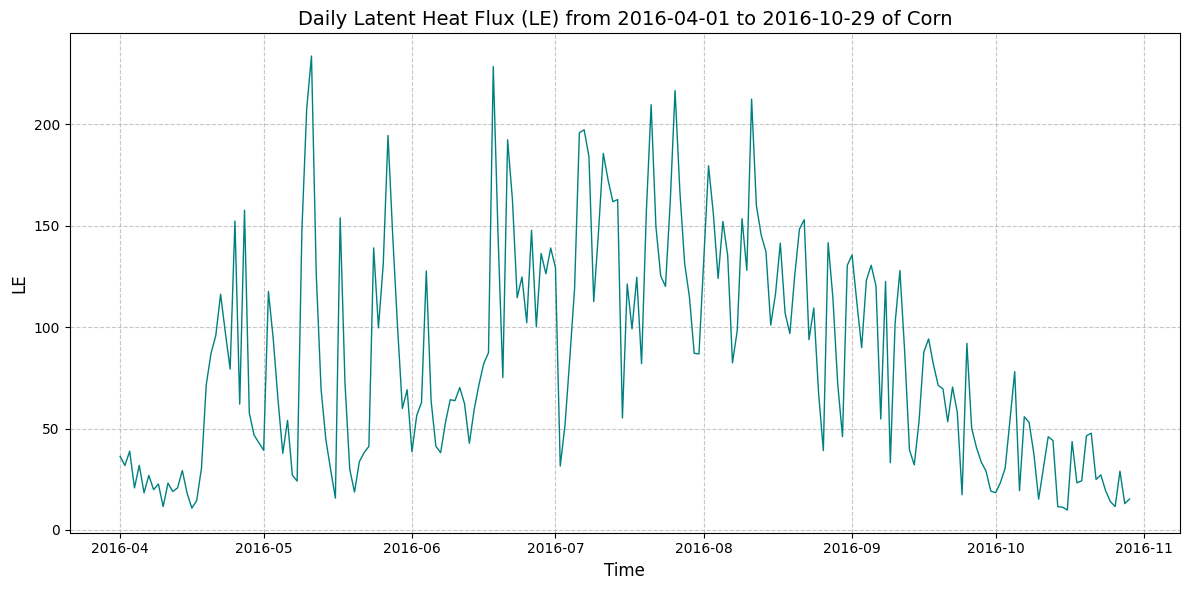

In [38]:
plot_LE_daily(daily_avg_df,start_date,end_date)

In [39]:
df2[[
 'TA',
 'SW_IN',
 'LW_IN',
 'VPD',
 'RH',
 'TS',
 'SWC',
 'LE',]].corr()

,TA,SW_IN,LW_IN,VPD,RH,TS,SWC,LE
TA,1.000000,0.376694,0.887811,0.673964,-0.184856,0.947657,0.474143,0.492216
SW_IN,0.376694,1.000000,0.201784,0.590380,-0.488731,0.370459,0.090844,0.757248
LW_IN,0.887811,0.201784,1.000000,0.460715,0.102637,0.871415,0.411245,0.416979
VPD,0.673964,0.590380,0.460715,1.000000,-0.702195,0.617249,0.198863,0.562697
RH,-0.184856,-0.488731,0.102637,-0.702195,1.000000,-0.102628,0.020768,-0.268478
TS,0.947657,0.370459,0.871415,0.617249,-0.102628,1.000000,0.485536,0.481338
SWC,0.474143,0.090844,0.411245,0.198863,0.020768,0.485536,1.000000,0.160773
LE,0.492216,0.757248,0.416979,0.562697,-0.268478,0.481338,0.160773,1.000000


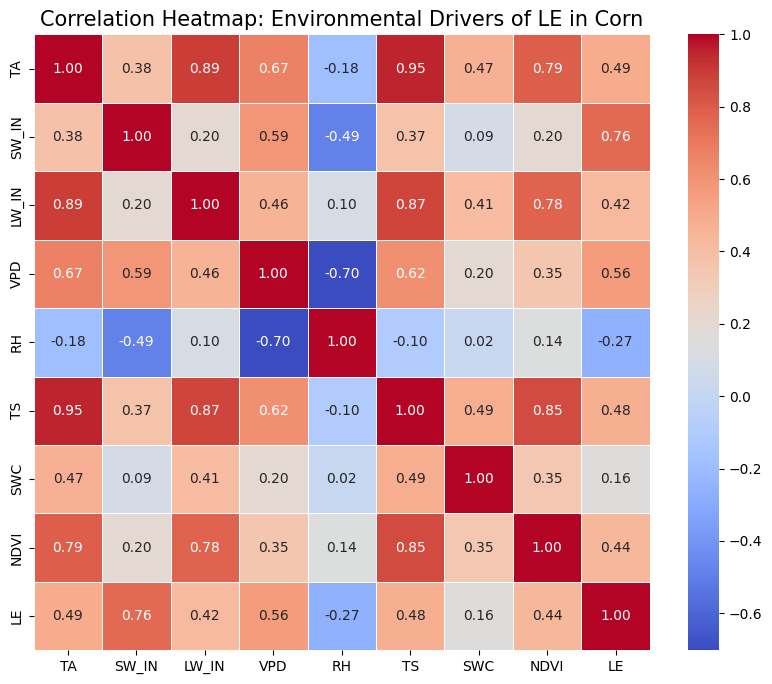

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df2[['TA', 'SW_IN', 'LW_IN', 'VPD', 'RH', 'TS', 'SWC','NDVI','LE']].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True,      
            fmt=".2f",       
            cmap='coolwarm',
            linewidths=0.5, 
            square=True)

plt.title('Correlation Heatmap: Environmental Drivers of LE in Corn', fontsize=15)
plt.savefig('Images/correlation.png')
plt.show()

In [41]:
df2.isnull().sum()

TA           0
SW_IN        0
LW_IN        0
VPD          0
PA           0
P            0
RH           0
TS           0
SWC          0
LE           0
NDVI         0
HOUR         0
MONTH        0
DAY          0
YEAR         0
MINUTE       0
timestamp    0
dtype: int64

In [42]:
from sklearn.model_selection import train_test_split
features = ['TA', 'SW_IN', 'LW_IN', 'VPD', 'RH', 'TS', 'SWC','NDVI']
target = 'LE'
X = df2[features]
y = df2[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Total samples: 67569
Training samples: 54055
Testing samples: 13514


In [43]:
df2.loc[55031:]

,TA,SW_IN,LW_IN,VPD,PA,P,RH,TS,SWC,LE,NDVI,HOUR,MONTH,DAY,YEAR,MINUTE,timestamp
55031,-14.16,226.6,234.5,0.678,97.93,0.130,66.8,-1.655,14.700,7.8,0.159269,9,2,17,2021,0,2021-02-17 09:00:00
55032,-13.45,430.6,220.1,0.730,97.93,0.094,66.3,-1.645,14.700,8.1,0.159269,10,2,17,2021,0,2021-02-17 10:00:00
55033,-10.36,307.9,259.5,0.950,97.89,0.009,65.8,-1.460,14.767,8.8,0.159269,15,2,17,2021,0,2021-02-17 15:00:00
55034,-10.52,145.6,261.9,0.908,97.91,0.009,66.9,-1.420,14.767,7.2,0.159269,16,2,17,2021,0,2021-02-17 16:00:00
55035,-10.73,37.6,260.2,0.839,97.95,0.007,68.9,-1.385,14.767,5.4,0.159269,17,2,17,2021,0,2021-02-17 17:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68776,3.56,0.1,305.8,1.727,96.41,0.000,78.1,-0.375,17.033,-2.3,0.228910,19,12,31,2022,0,2022-12-31 19:00:00
68777,3.20,0.0,304.7,1.638,96.49,0.000,78.7,-0.380,17.100,-1.1,0.228910,20,12,31,2022,0,2022-12-31 20:00:00
68778,2.16,0.1,307.7,1.292,96.52,0.000,81.9,-0.390,17.100,0.0,0.228910,21,12,31,2022,0,2022-12-31 21:00:00
68779,1.18,0.1,293.9,0.945,96.54,0.000,85.8,-0.400,17.133,2.2,0.228910,22,12,31,2022,0,2022-12-31 22:00:00


In [171]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit,RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
import numpy as np




xgb_model = xgb.XGBRegressor(
    tree_method='hist',    
    device='cuda',         

    # objective='reg:tweedie', # Tweedie is excellent for skewed environmental flux data
    # tweedie_variance_power=1.5,
    objective='reg:squarederror', 
    random_state=42
)
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100,200,400,500, 1000],
    'min_child_weight': [1, 5, 10],
    'reg_lambda': [1, 10, 100],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=1  
)


print("Training starting")
random_search.fit(X_train, y_train)


print("\n--- Best Parameters ---")
print(random_search.best_params_)

best_model = random_search.best_estimator_


Training starting
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=5, n_estimators=400, reg_lambda=10, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=5, n_estimators=400, reg_lambda=10, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=5, n_estimators=400, reg_lambda=10, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=5, n_estimators=400, reg_lambda=10, subsample=0.8; total time=   1.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=5, n_estimators=400, reg_lambda=10, subsample=0.8; total time=   1.3s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=1000, reg_lambda=100, subsample=0.8; total time=   2.9s
[CV] END col

In [46]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


best_params = {
    'subsample': 0.7,
    'reg_lambda': 10,
    'n_estimators': 100,
    'min_child_weight': 10,
    'max_depth': 5,
    'learning_rate': 0.1,
    'colsample_bytree': 0.8,
    'objective': 'reg:squarederror',  # Standard for regression tasks
    'random_state': 42                # For reproducibility
}

# 2. Initialize the model
# We unpack the dictionary using **
best_model = xgb.XGBRegressor(**best_params)

# 3. Fit the model
# Assuming X is your feature matrix and y is your target (e.g., ET or Soil Moisture)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
best_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = best_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred):.4f}")

R2 Score: 0.8875
RMSE: 1012.8337


In [59]:
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("\n--- Training Performance ---")
print(f"Train R2 Score: {r2_score(y_train, y_pred_train):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print("\n--- Testing Performance ---")
print(f"Test R2 Score: {r2_score(y_test, y_pred_test):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")


--- Training Performance ---
Train R2 Score: 0.9246
Train MAE: 15.0802
Test RMSE: 24.7559

--- Testing Performance ---
Test R2 Score: 0.8875
Test MAE: 19.5472
Test RMSE: 31.8250


In [60]:
def performance_check(X_test,y_test):
    y_pred_test = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    return r2,mae,rmse

In [61]:
performance_check(X_test,y_test)

(0.8874966086122269, 19.54723693488903, np.float64(31.825047580880103))

In [62]:
def give_performance(df,start,end):
    df_test = get_df_in_range(df, start, end)
    X_test = df_test[features]
    y_test = df_test[target]
    r2,mae,rmse = performance_check(X_test,y_test)
    return r2,mae,rmse

In [63]:
# start = 20210217
# end = 20221231
# give_performance(df2,start,end)

In [64]:
def get_performance_summary(df, date_ranges,daily=False):
    results = []
    r2,mae,rmse = [-1,-1,-1]
    for start, end ,crop , site in date_ranges:
        
        r2, mae, rmse = give_performance(df,start, end)
                
        results.append({
            'Start': start,
            'End': end,
            'Site':site,
            'Crop':crop,
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })
    
    return pd.DataFrame(results)
def get_performance_summary_daily(df, date_ranges):
    df_t = pred_add(df,date_ranges[0][0],date_ranges[-1][1])
    results = []
    for start, end ,crop , site in date_ranges:
        df_test = get_df_in_range(df_t, start, end)
        df_test = df_test.groupby(['YEAR','MONTH','DAY']).mean().reset_index()
        r2 = r2_score(df_test['LE'],df_test['PREDICTED'])
        mae = mean_absolute_error(df_test['LE'],df_test['PREDICTED'])
        rmse = np.sqrt(mean_squared_error(df_test['LE'],df_test['PREDICTED']))
        results.append({
            'Start': start,
            'End': end,
            'Site':site,
            'Crop':crop,
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })
    return pd.DataFrame(results)

In [65]:
# df_final_results_1 = get_performance_summary(df2, site_usne1)

In [66]:
# best_model.save_model("ET_model.json")

In [67]:
# plot_actual_predicted_scatter(y_test,y_test_pred,'Hourly','US-Ne1(Training)')
# plot_residual_actual_predicted(y_test,y_test_pred,'Hourly','US-Ne1(Training)')
# df_result = pred_add(df2,start,end)
# plot_timeseries(df_result,'2021-02-17','2022-12-31','Hourly','US-Ne1(Training)')

# Visulization

In [68]:
def plot_actual_predicted_scatter(y_test,y_test_pred,duration,site_id):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_test_pred, alpha=0.5, color='teal')
    max_val = max(max(y_test), max(y_test_pred))
    min_val = min(min(y_test), min(y_test_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')
    plt.title('Actual vs Predicted (Scatter Plot)',fontsize=14, fontweight='bold')
    plt.xlabel('Actual (W/m2)')
    plt.ylabel('Predicted (W/m2)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'Results/{duration}_1_{site_id}.png')
    plt.show()
    
def plot_residual_actual_predicted(y_test,y_test_pred,duration,site_id):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_test - y_test_pred, alpha=0.5, color='teal')
    max_val = max(max(y_test), max(y_test_pred))
    min_val = min(min(y_test), min(y_test_pred))
    plt.axhline(0, color='red', linewidth=2,linestyle='--')
    plt.title('Residual Plot',fontsize=14, fontweight='bold')
    plt.xlabel('Actual (W/m2)')
    plt.ylabel('Residual(W/m2)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'Results/{duration}_2_{site_id}.png')
    plt.show()
    
def plot_timeseries(df_result,start_date,end_date,duration,site_id):
    df_result['Date'] = pd.to_datetime(df_result[['YEAR', 'MONTH', 'DAY','HOUR']])
    mask = (df_result['Date'] >= start_date) & (df_result['Date'] <= end_date)
    df_plot = df_result.loc[mask].copy() 
    df_plot = df_plot.sort_values(by='Date')
    plt.figure(figsize=(15, 6))
    plt.plot(df_plot['Date'], df_plot['LE'], label='Actual', marker='o', markersize=3)
    plt.plot(df_plot['Date'], df_plot['PREDICTED'], label='Predicted', linestyle='--',color='r')
    plt.title(f'Actual vs Predicted LE from {start_date} to {end_date}', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('LE (W/m2)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.savefig(f'Results/{duration}_3_{site_id}.png')
    plt.show()

def plot_daily_timeseries(df_result,start_date,end_date,duration,site_id):
    df_result['Date'] = pd.to_datetime(df_result[['YEAR', 'MONTH', 'DAY', 'HOUR']])
    mask = (df_result['Date'] >= start_date) & (df_result['Date'] <= end_date)
    df_filtered = df_result.loc[mask].copy()
    df_daily = df_filtered.set_index('Date')[['LE', 'PREDICTED']].resample('D').mean().reset_index()
    plt.figure(figsize=(15, 6))
    plt.plot(df_daily['Date'], df_daily['LE'], label='Actual (Daily Avg)', marker='o', markersize=4, linewidth=1.5)
    plt.plot(df_daily['Date'], df_daily['PREDICTED'], label='Predicted (Daily Avg)', linestyle='--', color='r', linewidth=1.5)
    plt.title(f'Daily Average: Actual vs Predicted LE from {start_date} to {end_date}', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Average LE (W/m2)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.savefig(f'Results/{duration}_3_{site_id}.png')
    plt.show()

def dateTimePreprocess(df1):
    df1['TIMESTAMP_START']=pd.to_datetime(df1['TIMESTAMP_START'].astype(str), format='%Y%m%d%H%M')
    df1['HOUR'] = df1['TIMESTAMP_START'].dt.hour
    df1['MONTH']  = df1['TIMESTAMP_START'].dt.month
    df1['DAY'] = df1['TIMESTAMP_START'].dt.day
    df1['YEAR']  = df1['TIMESTAMP_START'].dt.year
    df1['HOUR'] = df1['TIMESTAMP_START'].dt.hour
    df1['MINUTE'] = df1['TIMESTAMP_START'].dt.minute
    df1.drop(['TIMESTAMP_START'],axis=1,inplace=True)
    return df1
    
def test_site(df,start,end,duration,site_id):
    df_test = get_df_in_range(df, start, end)
    X_test_new = df_test[features]
    y_test_new = df_test[target]
    y_test_pred_new = best_model.predict(X_test_new)
    plot_actual_predicted_scatter(y_test_new,y_test_pred_new,duration,site_id)
    plot_residual_actual_predicted(y_test_new,y_test_pred_new,duration,site_id)
    
def pred_add(df,start,end):
    df_test = get_df_in_range(df, start, end)
    X_test_new = df_test[features]
    y_test_new = df_test[target]
    y_test_pred = best_model.predict(X_test_new)
    predicted = pd.DataFrame(y_test_pred,columns = ["PREDICTED"])
    df_test_reset = df_test.reset_index(drop=True)
    predicted_reset = predicted.reset_index(drop=True)
    df_result = pd.concat([df_test_reset[['YEAR','MONTH','DAY','HOUR','LE']],predicted_reset],axis=1)
    return df_result
def format_date_simple(date_int):
    date_str = str(date_int)
    return f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}"

def site_test(df,i):
    start = df[i-1][0]
    end = df[i-1][1]
    start_date = format_date_simple(start)
    end_date = format_date_simple(end)
    return start,end,start_date,end_date


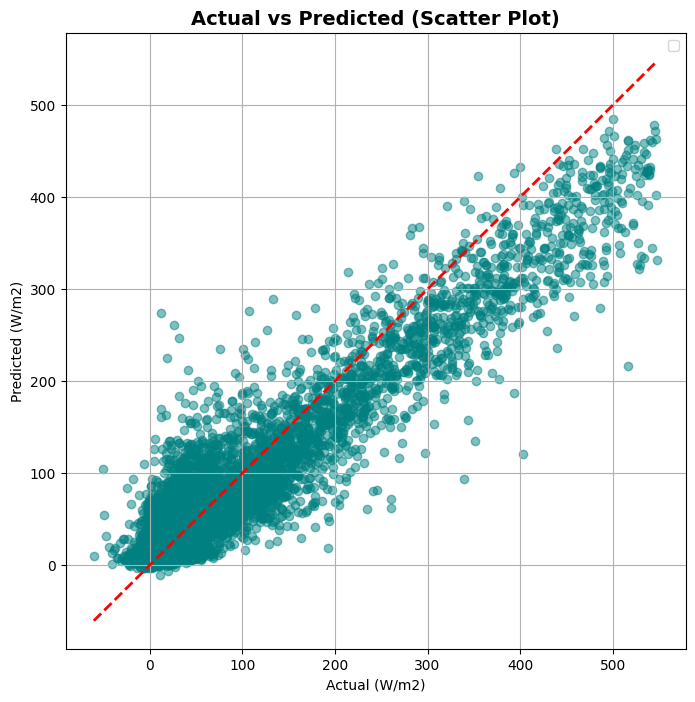

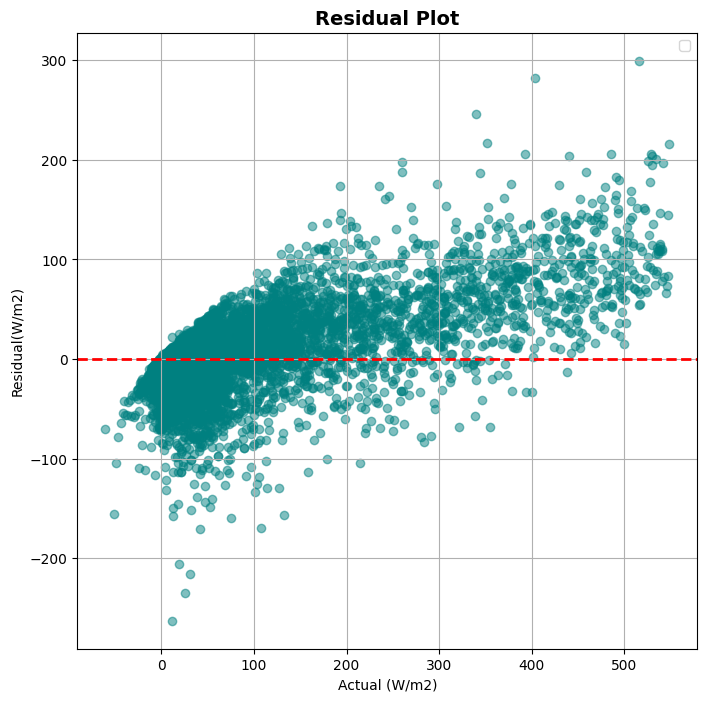

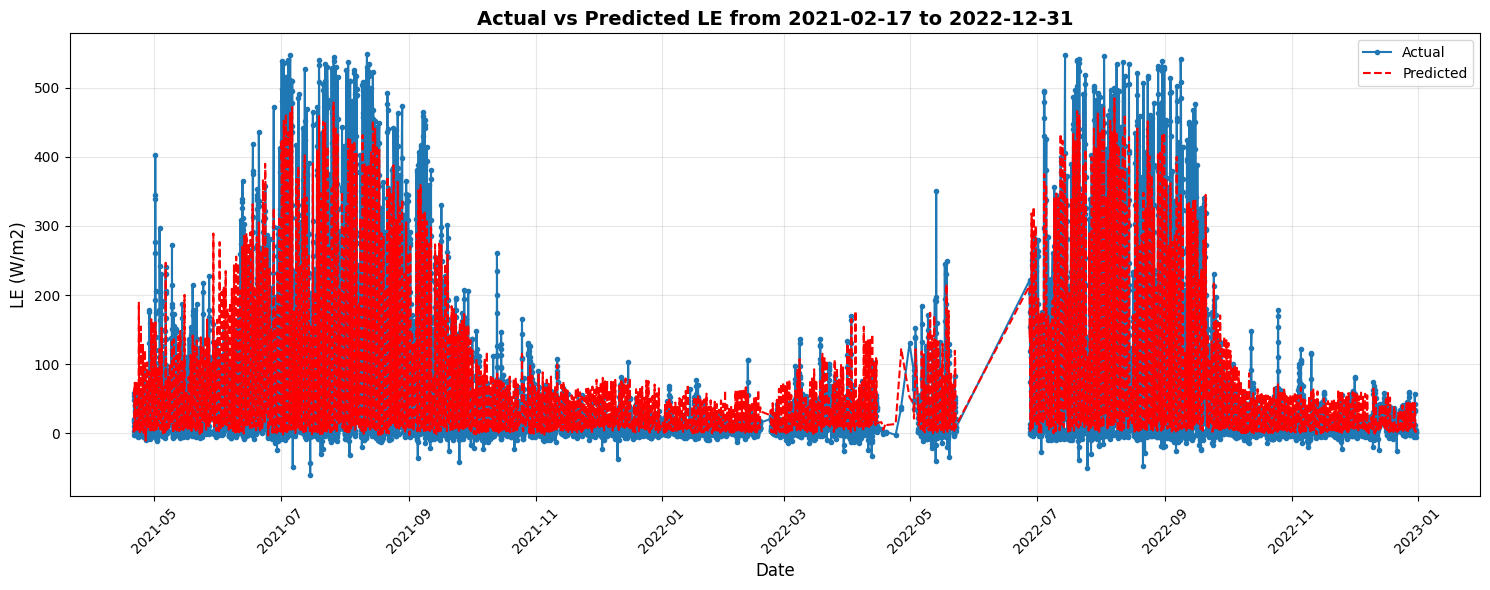

In [70]:
start = 20210421
end = 20221231
plot_actual_predicted_scatter(y_test,y_test_pred,'Hourly','US-Ne1(Training)')
plot_residual_actual_predicted(y_test,y_test_pred,'Hourly','US-Ne1(Training)')
df_result = pred_add(df2,start,end)
plot_timeseries(df_result,'2021-02-17','2022-12-31','Hourly','US-Ne1(Training)')

In [71]:
site_usne1 = [
    (20140421, 20141029,'CORN','US-Ne1'), 
    (20150429, 20151026,'CORN','US-Ne1'),
    (20160519, 20160926,'CORN','US-Ne1'),
    (20170427, 20171026,'CORN','US-Ne1'),
    (20180508,20181031,'CORN','US-Ne1'),
    (20200420,20200917,'CORN','US-Ne1'),
    (20210427,20211019,'CORN','US-Ne1')
]
site_usne2 = [
    (20140520, 20141010,'SOYABEAN','US-Ne2'), 
    (20150429, 20151026,'CORN','US-Ne2'),
    (20160518, 20161024,'SOYABEAN','US-Ne2'),
    (20170508, 20171011,'CORN','US-Ne2'),
    (20180510,20181022,'SOYABEAN','US-Ne2'),
    (20190423,20191107,'CORN','US-Ne2'),
    (20200505,20201005,'SOYABEAN','US-Ne2'),
    (20210426,20211019,'CORN','US-Ne2')
]
site_usarm  = [
    (20080428, 20080925,'CORN','US-ARM'), 
    (20080929, 20090618,'WHEAT','US-ARM'),
    (20090929, 20100622,'WHEAT','US-ARM'),
    (20111025, 20120521,'WHEAT','US-ARM'),
    (20121010, 20130621,'WHEAT','US-ARM'),
    (20131025, 20140607,'WHEAT','US-ARM'),
]
site_usbi2 = [
    (20170428, 20170925,'CORN','US-Bi2'), 
    (20180428, 20180925,'CORN','US-Bi2'),
    (20190428, 20190925,'CORN','US-Bi2'),
    (20200428, 20200925,'CORN','US-Bi2'),
    (20210428, 20210925,'CORN','US-Bi2'),
    (20220428, 20220925,'CORN','US-Bi2'),
]

In [72]:
site = site_usne1
crop_i = 7
df_test_site = pd.read_csv('full_train_US-Ne1.csv')
df_test_new = dateTimePreprocess(df_test_site)

In [73]:
# start = 20210217
# end = 20221231
# start_date = '2021-02-17'
# end_date = '2022-12-31'
# df_result = pred_add(df_test_new,start,end)
# df_temp = df_result.groupby(['YEAR','MONTH','DAY']).mean().reset_index()
# plot_actual_predicted_scatter(df_temp['LE'],df_temp['PREDICTED'],'DAILY','COMPLETE_US-Bi2')
# plot_daily_timeseries(df_temp,start_date,end_date,'Hourly','US_Ne1_daily')

In [74]:
start,end,start_date,end_date = site_test(site,crop_i)
df_result = pred_add(df_test_new,start,end)

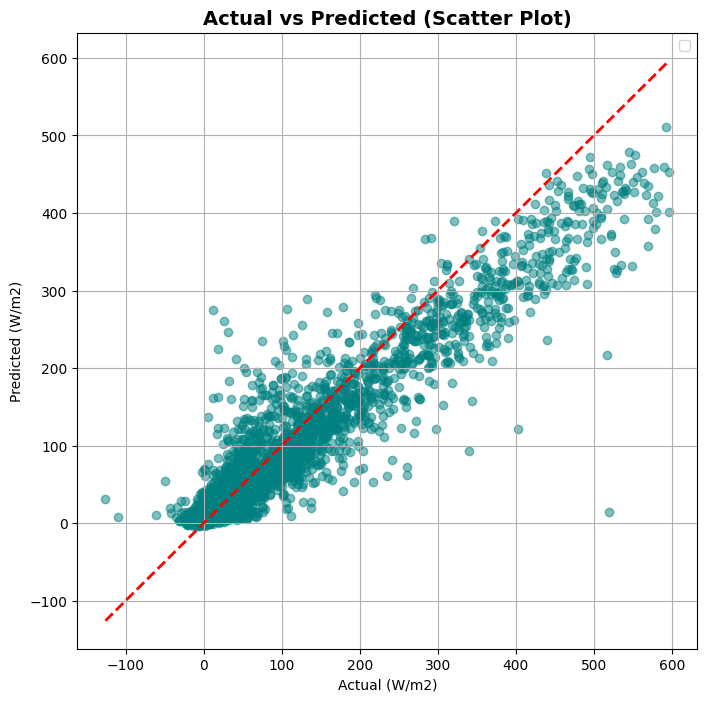

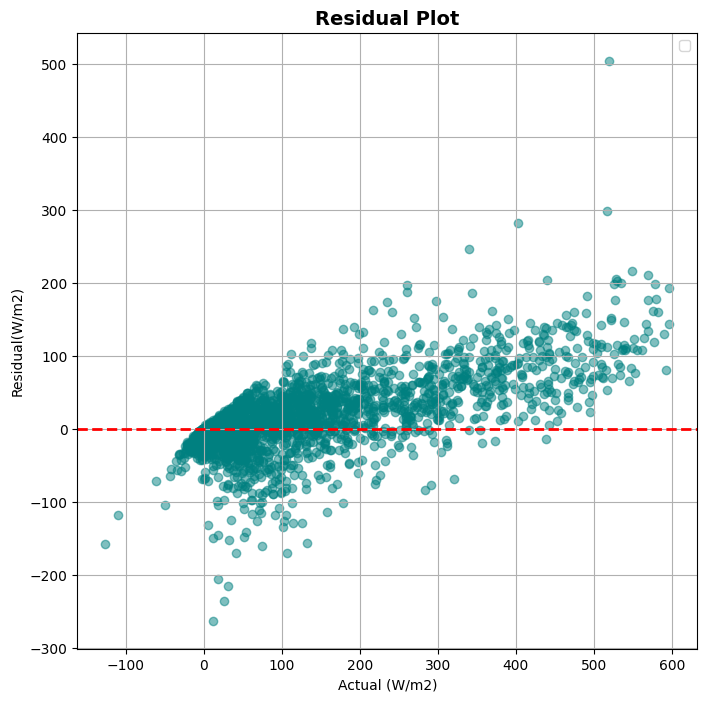

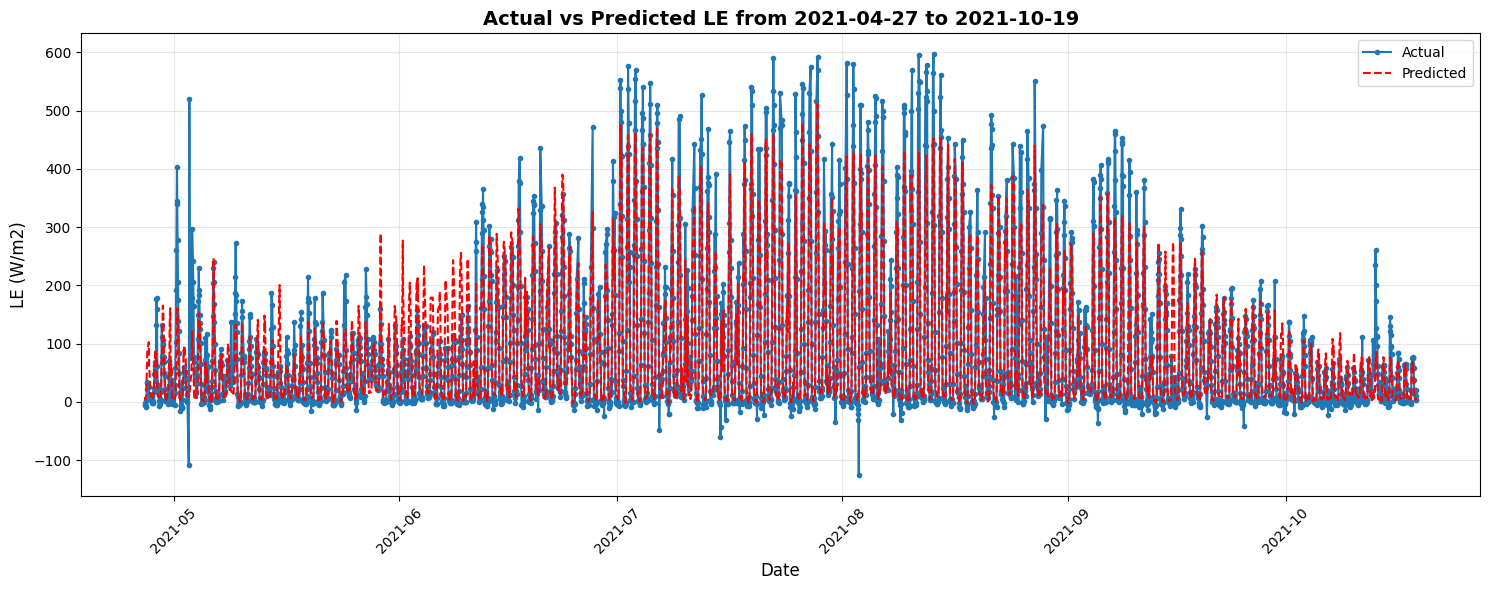

In [75]:
test_site(df_test_new,start,end,'Hourly',f"{site[crop_i-1][3]}_{site[crop_i-1][2]}_{site[crop_i-1][0]}")
df_result = pred_add(df_test_new,start,end)
plot_timeseries(df_result,start_date,end_date,'Hourly',f"{site[crop_i-1][3]}_{site[crop_i-1][2]}_{site[crop_i-1][0]}")

In [76]:
df_result_daily = df_result.groupby(['YEAR','MONTH','DAY']).mean().reset_index()

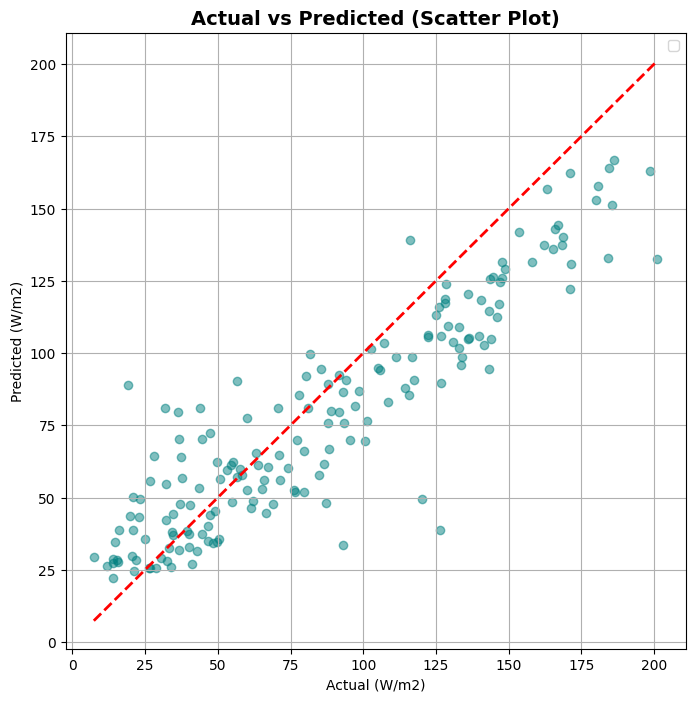

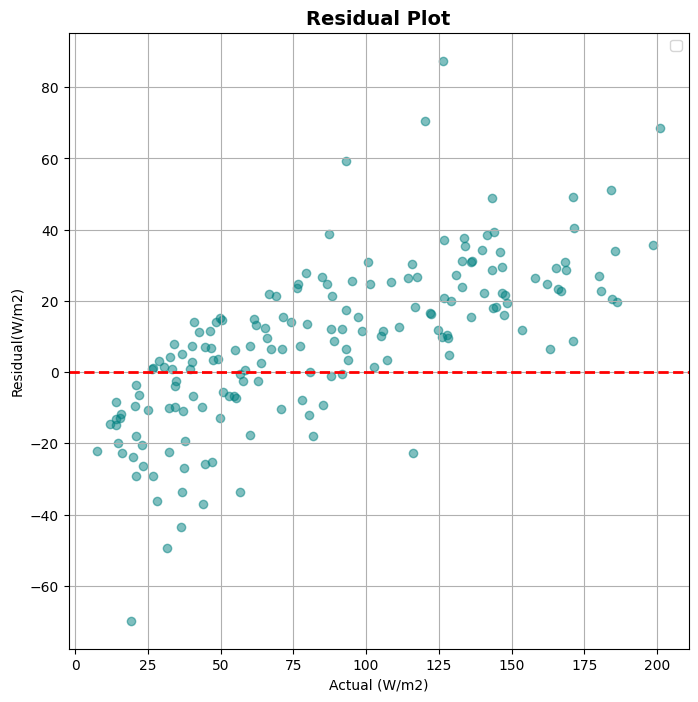

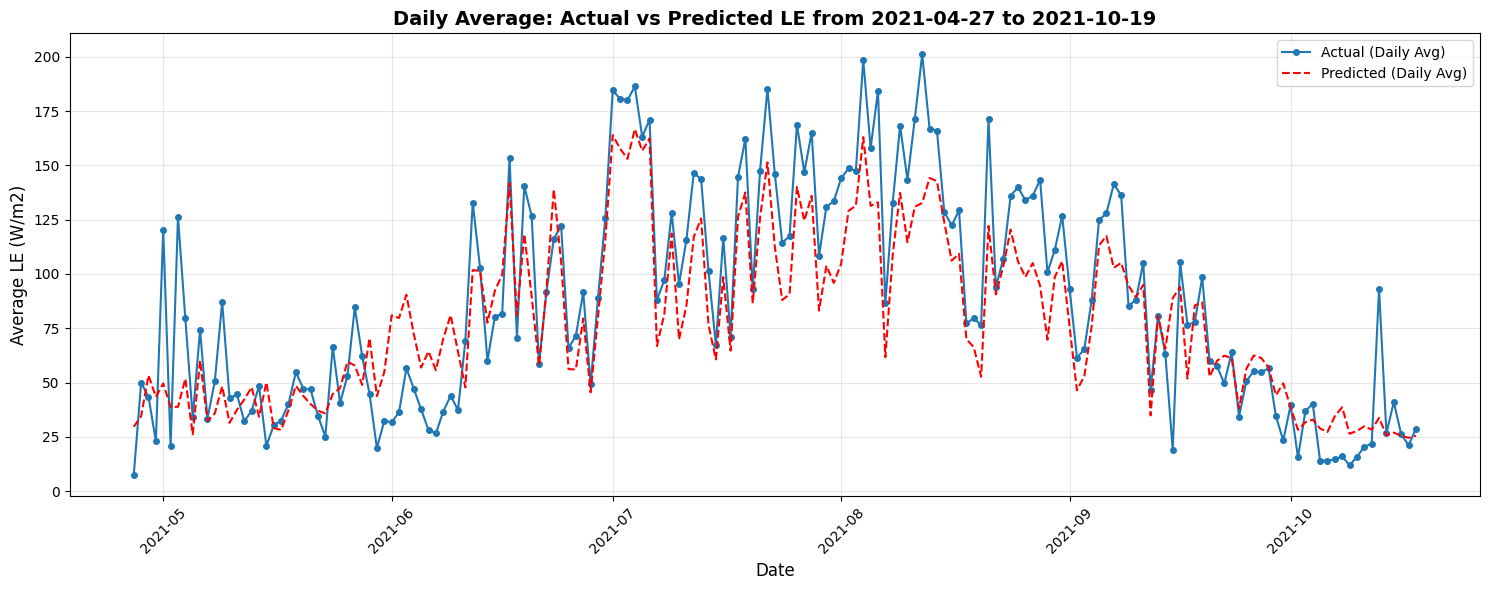

In [77]:
plot_actual_predicted_scatter(df_result_daily['LE'],df_result_daily['PREDICTED'],'Daily',f"{site[crop_i-1][3]}_{site[crop_i-1][2]}_{site[crop_i-1][0]}")
plot_residual_actual_predicted(df_result_daily['LE'],df_result_daily['PREDICTED'],'Daily',f"{site[crop_i-1][3]}_{site[crop_i-1][2]}_{site[crop_i-1][0]}")
plot_daily_timeseries(df_result_daily,start_date,end_date,'Daily',f"{site[crop_i-1][3]}_{site[crop_i-1][2]}_{site[crop_i-1][0]}")

In [78]:
df_final_results = get_performance_summary(df_test_new, site)
df_final_results

,Start,End,Site,Crop,R2,MAE,RMSE
0,20140421,20141029,US-Ne1,CORN,0.865561,21.778958,39.337020
1,20150429,20151026,US-Ne1,CORN,0.917244,21.572100,38.383667
2,20160519,20160926,US-Ne1,CORN,0.924572,22.072597,37.379729
3,20170427,20171026,US-Ne1,CORN,0.934487,18.846603,29.353501
4,20180508,20181031,US-Ne1,CORN,0.925412,16.814734,29.284944
5,20200420,20200917,US-Ne1,CORN,0.920334,21.441442,35.155966
6,20210427,20211019,US-Ne1,CORN,0.882102,26.183032,43.147352


In [79]:
df_final_results = get_performance_summary_daily(df_test_new, site)
df_final_results

,Start,End,Site,Crop,R2,MAE,RMSE
0,20140421,20141029,US-Ne1,CORN,0.822413,14.537442,19.147552
1,20150429,20151026,US-Ne1,CORN,0.871388,13.664239,18.574742
2,20160519,20160926,US-Ne1,CORN,0.853973,12.993104,19.139964
3,20170427,20171026,US-Ne1,CORN,0.904327,10.365446,14.114587
4,20180508,20181031,US-Ne1,CORN,0.919315,9.067680,12.684744
5,20200420,20200917,US-Ne1,CORN,0.855197,13.327269,18.559958
6,20210427,20211019,US-Ne1,CORN,0.773631,19.046516,24.036456


In [80]:
df_test_site = pd.read_csv('full_train_US-Ne1.csv')
site = site_usne1
df_test_new = dateTimePreprocess(df_test_site)
df_final_results_1 = get_performance_summary_daily(df_test_new, site)

In [81]:
df_final_results_1

,Start,End,Site,Crop,R2,MAE,RMSE
0,20140421,20141029,US-Ne1,CORN,0.822413,14.537442,19.147552
1,20150429,20151026,US-Ne1,CORN,0.871388,13.664239,18.574742
2,20160519,20160926,US-Ne1,CORN,0.853973,12.993104,19.139964
3,20170427,20171026,US-Ne1,CORN,0.904327,10.365446,14.114587
4,20180508,20181031,US-Ne1,CORN,0.919315,9.067680,12.684744
5,20200420,20200917,US-Ne1,CORN,0.855197,13.327269,18.559958
6,20210427,20211019,US-Ne1,CORN,0.773631,19.046516,24.036456


In [83]:
# df_all_site_daily = pd.concat([df_final_results_1, df_final_results_2, df_final_results_3,df_final_results_4]).reset_index()

In [84]:
df_test_site = pd.read_csv('full_test_US-Bi2.csv')
site = site_usbi2
df_test_new = dateTimePreprocess(df_test_site)
df_final_results_h4 = get_performance_summary(df_test_new, site)

In [972]:
 # df_all_site_hourly = pd.concat([df_final_results_h1, df_final_results_h2, df_final_results_h3,df_final_results_h4]).reset_index()

In [86]:
# df_all_site_daily

In [88]:
# df_all_site_daily['MAE'].min(),df_all_site_daily['MAE'].max(),df_all_site_daily['MAE'].mean()

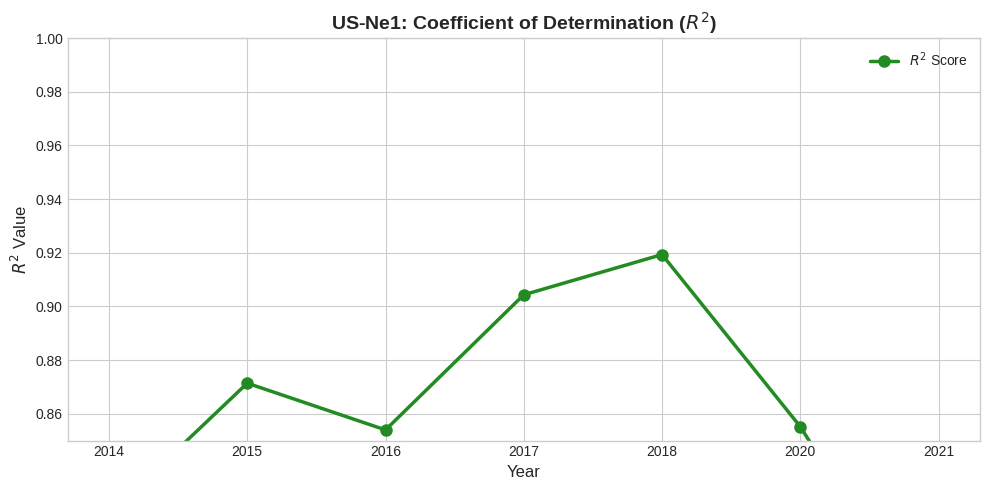

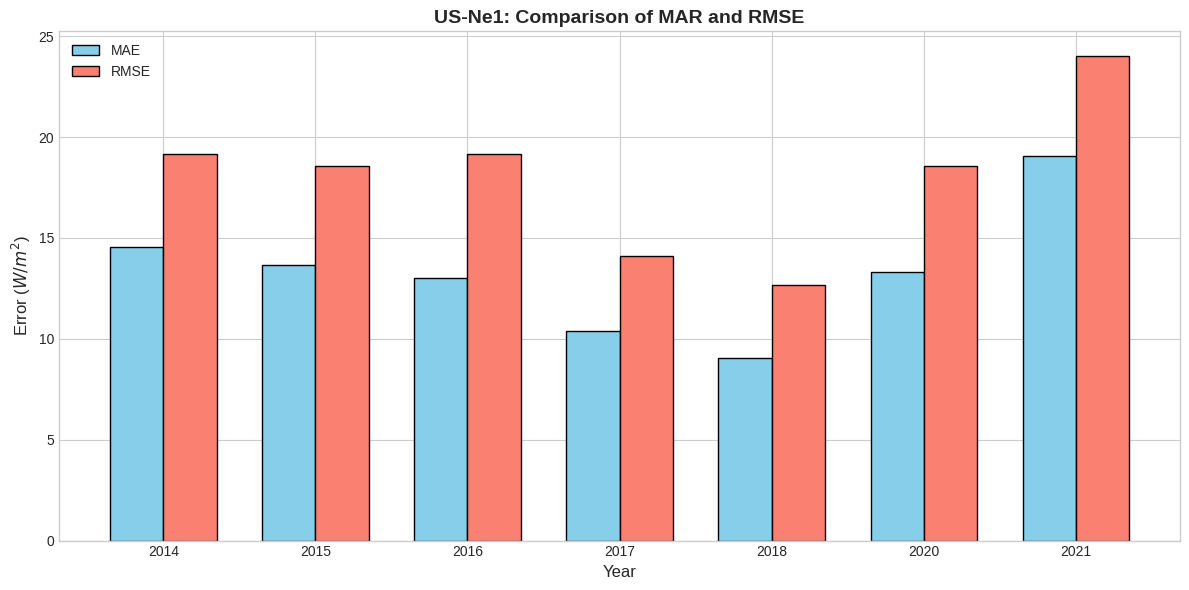

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Formatting the year for the X-axis
# Assuming your 'Start' column is in YYYYMMDD format
df_final_results_1['Year'] = df_final_results_1['Start'].astype(str).str[:4]

# Set a professional style
plt.style.use('seaborn-v0_8-whitegrid')

# --- 1. LINE PLOT: R2 PERFORMANCE ---
plt.figure(figsize=(10, 5))
plt.plot(df_final_results_1['Year'], df_final_results_1['R2'], 
         marker='o', markersize=8, color='forestgreen', linewidth=2.5, label='$R^2$ Score')

plt.title('US-Ne1: Coefficient of Determination ($R^2$)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('$R^2$ Value', fontsize=12)
plt.ylim(0.85, 1.0) # Zooming in to show the high-performance stability
plt.legend()
plt.tight_layout()
plt.savefig('Results/R2_US-Ne1_Corn.png')
plt.show()

# --- 2. BAR PLOT: ERROR METRICS (MAE vs RMSE) ---
x = np.arange(len(df_final_results_1['Year']))
width = 0.35 # Width of the bars

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, df_final_results_1['MAE'], width, label='MAE', color='skyblue', edgecolor='black')
plt.bar(x + width/2, df_final_results_1['RMSE'], width, label='RMSE', color='salmon', edgecolor='black')

plt.title('US-Ne1: Comparison of MAR and RMSE', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Error ($W/m^2$)', fontsize=12)
plt.xticks(x, df_final_results_1['Year'])
plt.legend()
plt.tight_layout()
plt.savefig('Results/MAE_MSE_US-Ne1_Corn.png')
plt.show()

In [94]:
# def plot_bar_mae_mse(df_final_results,site_id):
#     df_ne1 = df_final_results[df_final_results['Site'] == site_id].copy()
#     df_ne1['Year'] = df_ne1['Start'].astype(str).str[:4]
#     df_ne1 = df_ne1.sort_values('Year')
    
#     # 2. Setup Plot
#     x = np.arange(len(df_ne1['Year']))
#     width = 0.35 
    
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # Grouped Bars
#     rects1 = ax.bar(x - width/2, df_ne1['MAE'], width, label='MAE', color='#3498db', edgecolor='black', alpha=0.8)
#     rects2 = ax.bar(x + width/2, df_ne1['RMSE'], width, label='RMSE', color='#e74c3c', edgecolor='black', alpha=0.8)
    
#     # Formatting
#     ax.set_xlabel('Growing Season (Year)', fontsize=12, fontweight='bold')
#     ax.set_ylabel('Error Magnitude ($W/m^2$)', fontsize=12, fontweight='bold')
#     ax.set_title(f'Fig 2: Annual Error Metrics for {site_id} (Training Site)', fontsize=14, fontweight='bold', pad=15)
#     ax.set_xticks(x)
#     ax.set_xticklabels(df_ne1['Year'])
#     ax.legend(loc='upper left', frameon=True)
#     ax.set_ylim(0, max(df_ne1['RMSE']) + 10) # Dynamic limit
    
#     # Add grid for readability
#     ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    
#     plt.tight_layout()
#     plt.savefig(f'Results/Fig_mae_rmse_{site_id}.png', dpi=300)
#     plt.show()

In [95]:
# plot_bar_mae_mse(df_all_site_daily,'US-Ne1')

In [96]:
# df_final_results_h4

In [97]:
# df_all_site_daily[df_all_site_daily['Site']=='US-ARM']

In [98]:
# !pip install cartopy

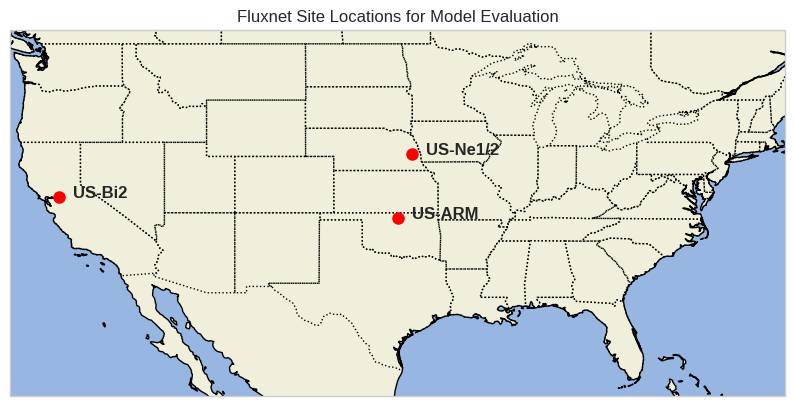

In [99]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define your site coordinates
sites = {
    'US-Ne1/2': (-96.47, 41.16),
    'US-ARM': (-97.48, 36.60),
    'US-Bi2': (-121.53, 38.10)
}

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES, linestyle=':')

# Set the extent to show the USA
ax.set_extent([-125, -70, 24, 50], crs=ccrs.PlateCarree())

# Plot the sites
for name, (lon, lat) in sites.items():
    plt.plot(lon, lat, 'ro', markersize=8, transform=ccrs.PlateCarree())
    plt.text(lon + 1, lat, name, transform=ccrs.PlateCarree(), fontsize=12, fontweight='bold')

plt.title("Fluxnet Site Locations for Model Evaluation")
plt.savefig("site_map.png", dpi=300, bbox_inches='tight')
plt.show()

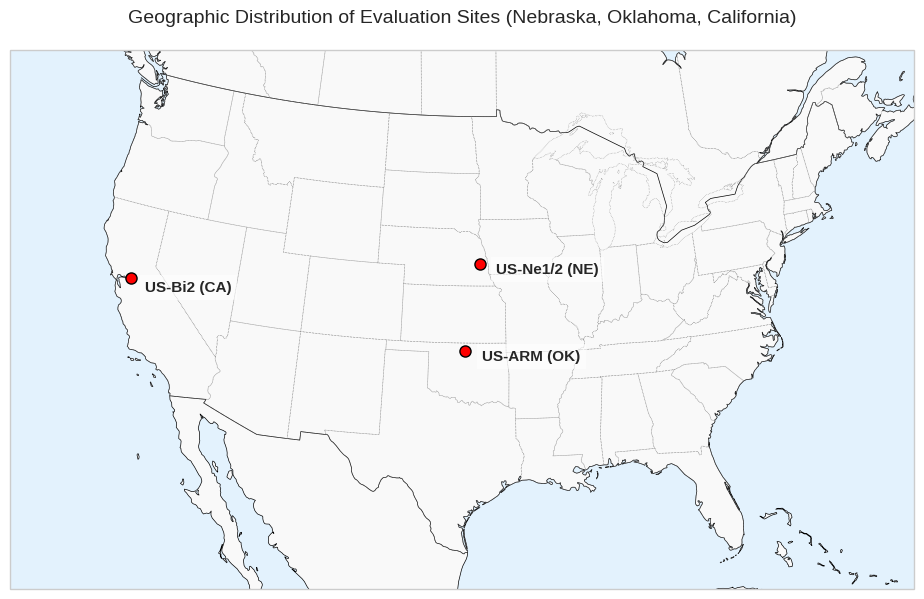

In [100]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Define your site coordinates (Longitude, Latitude)
sites = {
    'US-Ne1/2 (NE)': (-96.47, 41.1651),
    'US-ARM (OK)': (-97.48, 36.60),
    'US-Bi2 (CA)': (-121.53, 38.10)
}

# 2. Create the figure with a professional projection (Albers Equal Area)
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.AlbersEqualArea(central_longitude=-96, central_latitude=37.5))

# 3. Add geographical features for a "Research" look
ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')
ax.add_feature(cfeature.OCEAN, facecolor='#e3f2fd')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.4, edgecolor='gray')

# 4. Zoom in on the United States
ax.set_extent([-125, -70, 24, 50], crs=ccrs.PlateCarree())

# 5. Plot the coordinates
for name, (lon, lat) in sites.items():
    # Plot the red dot
    plt.plot(lon, lat, marker='o', color='red', markersize=8, 
             markeredgecolor='black', transform=ccrs.PlateCarree(), zorder=5)
    
    # Add the text label with a small offset
    plt.text(lon + 1.2, lat - 0.5, name, transform=ccrs.PlateCarree(), 
             fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.title("Geographic Distribution of Evaluation Sites (Nebraska, Oklahoma, California)", 
          fontsize=14, pad=20)

# 6. Save for Overleaf
plt.savefig("research_sites.png", dpi=300, bbox_inches='tight')
plt.show()

In [102]:
# import pandas as pd

# def process_et_results(df):
#     processed_df = df.copy()
#     processed_df['Year'] = processed_df['Start'].astype(str).str[:4]
#     processed_df = processed_df[['Year', 'Crop', 'R2', 'MAE', 'RMSE']]
#     # processed_df.columns = ['Year', 'croptype', 'r2', 'mae', 'mse']
    
#     return processed_df

# # Usage with your dataframe:
# # df_test_new = pd.read_csv("your_file.csv") 
# final_table = process_et_results(df_final_results_3)
# final_table

In [1334]:
# import dataframe_image as dfi
# dfi.export(final_table, 'CompTable/US-Bi2.png', table_conversion='matplotlib')

In [119]:
# df_res_daily

,YEAR,MONTH,DAY,HOUR,LE,PRED,Date
0,2021,4,27,11.700000,7.375000,29.586956,2021-04-27 11:42:00.000000000
1,2021,4,28,11.500000,49.854167,34.524025,2021-04-28 11:30:00.000000000
2,2021,4,29,11.826087,43.404348,53.333092,2021-04-29 11:49:33.913043479
3,2021,4,30,11.500000,22.979167,43.401699,2021-04-30 11:30:00.000000000
4,2021,5,1,11.500000,120.170833,49.556133,2021-05-01 11:30:00.000000000
...,...,...,...,...,...,...,...
171,2021,10,15,11.500000,40.970833,26.906759,2021-10-15 11:30:00.000000000
172,2021,10,16,11.500000,26.250000,25.491961,2021-10-16 11:30:00.000000000
173,2021,10,17,11.500000,21.037500,24.519745,2021-10-17 11:30:00.000000000
174,2021,10,18,11.500000,28.691667,25.448729,2021-10-18 11:30:00.000000000


In [104]:
df_res_daily = df_result_daily.rename(columns={'PREDICTED':'PRED'})

In [105]:
df_LE = df_res_daily[['LE','PRED','DAY','MONTH','YEAR']]

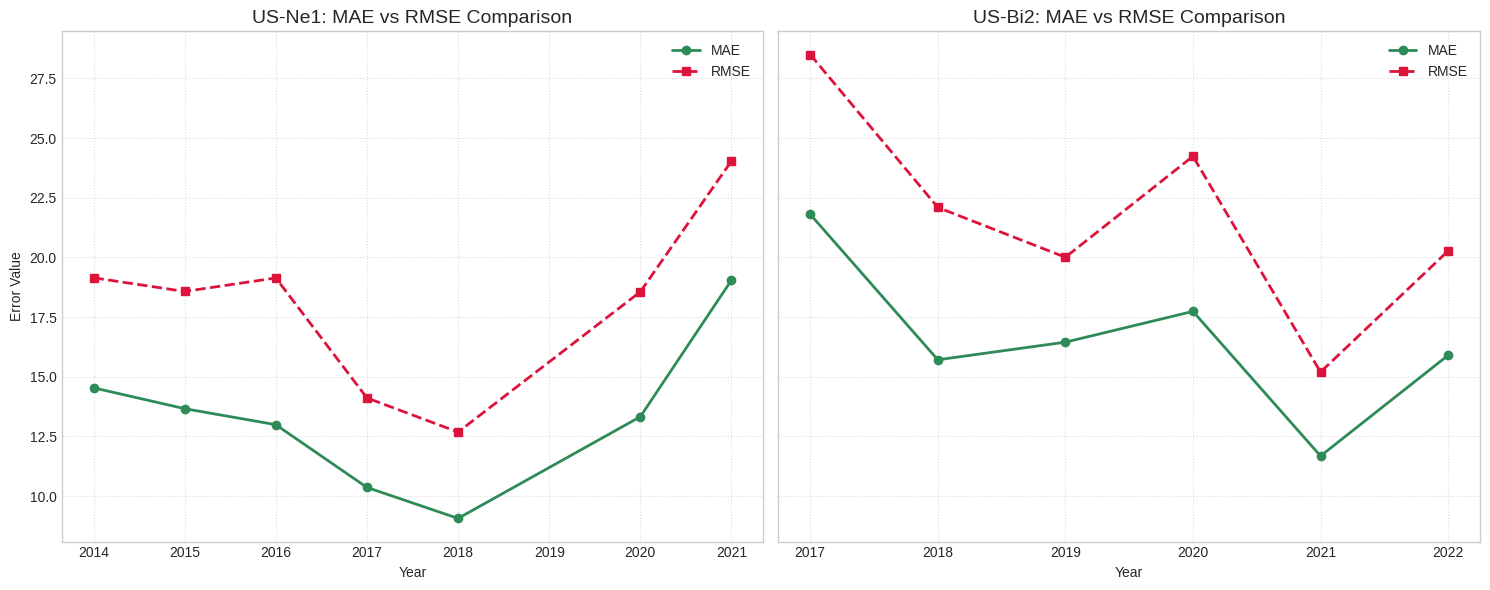

In [106]:
import matplotlib.pyplot as plt
import pandas as pd

# Data extracted from US-Ne1.png
data_ne1 = {
    'Year': [2014, 2015, 2016, 2017, 2018, 2020, 2021],
    'MAE': [14.537442, 13.664239, 12.993104, 10.365446, 9.067680, 13.327269, 19.046516],
    'RMSE': [19.147552, 18.574742, 19.139964, 14.114587, 12.684744, 18.559958, 24.036456]
}

# # Data extracted from US-Ne2.png
# data_ne2 = {
#     'Year': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
#     'MAE': [17.485200, 15.463517, 23.545338, 13.114073, 14.684034, 12.830678, 19.244883, 21.128385],
#     'RMSE': [22.242906, 21.189227, 29.173480, 16.662499, 18.913407, 17.099163, 24.832332, 25.729431]
# }
# site = 'US-Ne2'
# data_ne2 = data_ne2
# data_arm = {
#     'Year': [2008, 2009, 2011, 2012, 2013],
#     'MAE': [15.725724, 18.142017, 14.670946, 29.039301, 18.162176],
#     'RMSE': [21.144098, 23.500985, 20.806628, 46.243298, 27.612720]
# }
# site = 'US-ARM'
# data_ne2 = data_arm
data_bi2 = {
    'Year': [2017, 2018, 2019, 2020, 2021, 2022],
    'MAE': [21.806569, 15.712708, 16.450609, 17.739585, 11.682657, 15.899864],
    'RMSE': [28.500504, 22.096228, 20.007310, 24.237310, 15.198086, 20.273631]
}
site = 'US-Bi2'
data_ne2 = data_bi2
df_ne1 = pd.DataFrame(data_ne1)
df_ne2 = pd.DataFrame(data_ne2)

# Set up the visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plotting for US-Ne1
ax[0].plot(df_ne1['Year'], df_ne1['MAE'], marker='o', label='MAE', color='seagreen', linewidth=2)
ax[0].plot(df_ne1['Year'], df_ne1['RMSE'], marker='s', label='RMSE', color='crimson', linewidth=2, linestyle='--')
ax[0].set_title(f'US-Ne1: MAE vs RMSE Comparison', fontsize=14)
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Error Value')
ax[0].legend()
ax[0].grid(True, linestyle=':', alpha=0.7)

# Plotting for US-Ne2
ax[1].plot(df_ne2['Year'], df_ne2['MAE'], marker='o', label='MAE', color='seagreen', linewidth=2)
ax[1].plot(df_ne2['Year'], df_ne2['RMSE'], marker='s', label='RMSE', color='crimson', linewidth=2, linestyle='--')
ax[1].set_title(f'{site}: MAE vs RMSE Comparison', fontsize=14)
ax[1].set_xlabel('Year')
ax[1].legend()
ax[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig(f'Result_Inter/MAE_MSE_{site}.png')
plt.show()

,LE,PRED,DAY,MONTH,YEAR,DATE
0,7.375000,29.586956,27,4,2021,2021-04-27
1,49.854167,34.524025,28,4,2021,2021-04-28
2,43.404348,53.333092,29,4,2021,2021-04-29
3,22.979167,43.401699,30,4,2021,2021-04-30
4,120.170833,49.556133,1,5,2021,2021-05-01
...,...,...,...,...,...,...
171,40.970833,26.906759,15,10,2021,2021-10-15
172,26.250000,25.491961,16,10,2021,2021-10-16
173,21.037500,24.519745,17,10,2021,2021-10-17
174,28.691667,25.448729,18,10,2021,2021-10-18


In [107]:
df_LE_day = df_LE

In [108]:
# Create the date column
df_LE_day['DATE'] = pd.to_datetime(df_LE_day[['YEAR', 'MONTH', 'DAY']])

# Sort by date just in case they are out of order
df_LE_day = df_LE_day.sort_values('DATE')
df_LE_day['ET_actual'] = df_LE_day['LE']*0.0353
df_LE_day['ET_pred'] = df_LE_day['PRED']*0.0353

In [109]:
TAW = 1000*0.15*0.3
p = 0.55 + 0.04*(5 - 1.184359)
RAW = p*TAW

In [110]:
df_LE_day['ET_actual'].loc[:10].sum()

np.float64(21.598104207434755)

In [111]:
def makeTAW(df,Zr_min,Zr_max):
    for i in range(df.shape[0]):
        if i < 20:
            df.loc[i,'TAW'] = 1000*0.15*Zr_min
        elif i > 80:
            df.loc[i,'TAW'] = 1000*0.15*Zr_max 
        else:
            df.loc[i,'TAW'] = 1000*0.15*(Zr_min + (i+1)*(Zr_max - Zr_min)/60)
makeTAW(df_LE_day,0.3,1.4)

In [112]:
df_LE_day['p'] = 0.55 + 0.04*(5 - df_LE_day['ET_pred'])
df_LE_day['RAW'] = df_LE_day['p']*df_LE_day['TAW']

In [113]:
def no_of_water(df):
    sum_water = 0
    count = 0
    for i in range(df.shape[0]):
        sum_water = sum_water + df.loc[i,'ET_actual']
        if(sum_water > RAW):
            print(i)
            count = count + 1
            sum_water = 0
    print(count)
no_of_water(df_LE_day)

16
37
51
61
68
76
84
91
98
104
110
119
127
136
149
15


In [116]:
def no_of_water(df):
    sum_water = 0
    count = 0
    for i in range(df.shape[0]):
        sum_water = sum_water + df.loc[i,'ET_pred']
        print(f'DAY {i+1}: Water Lost {df.loc[i,'ET_pred']:.2f} mm')
        if(sum_water > RAW):
            print(f'DAY {i+1}: Irrigation of {sum_water:.2f} mm of water')
            count = count + 1
            sum_water = 0
    print(count)
no_of_water(df_LE_day)

DAY 1: Water Lost 1.04 mm
DAY 2: Water Lost 1.22 mm
DAY 3: Water Lost 1.88 mm
DAY 4: Water Lost 1.53 mm
DAY 5: Water Lost 1.75 mm
DAY 6: Water Lost 1.37 mm
DAY 7: Water Lost 1.37 mm
DAY 8: Water Lost 1.83 mm
DAY 9: Water Lost 0.92 mm
DAY 10: Water Lost 2.12 mm
DAY 11: Water Lost 1.14 mm
DAY 12: Water Lost 1.26 mm
DAY 13: Water Lost 1.70 mm
DAY 14: Water Lost 1.11 mm
DAY 15: Water Lost 1.32 mm
DAY 16: Water Lost 1.49 mm
DAY 17: Water Lost 1.69 mm
DAY 18: Water Lost 1.21 mm
DAY 19: Water Lost 1.77 mm
DAY 20: Water Lost 1.02 mm
DAY 21: Water Lost 0.99 mm
DAY 22: Water Lost 1.31 mm
DAY 23: Water Lost 1.71 mm
DAY 23: Irrigation of 32.77 mm of water
DAY 24: Water Lost 1.55 mm
DAY 25: Water Lost 1.41 mm
DAY 26: Water Lost 1.31 mm
DAY 27: Water Lost 1.26 mm
DAY 28: Water Lost 1.58 mm
DAY 29: Water Lost 1.67 mm
DAY 30: Water Lost 2.10 mm
DAY 31: Water Lost 2.04 mm
DAY 32: Water Lost 1.73 mm
DAY 33: Water Lost 2.49 mm
DAY 34: Water Lost 1.54 mm
DAY 35: Water Lost 1.93 mm
DAY 36: Water Lost 2.86 

In [115]:
irrigation_data = {
    'Day': [23, 39, 51, 61, 69, 78, 87, 96, 104, 111, 121, 132, 143, 159],
    'Irrigation_mm': [32.77, 32.04, 32.22, 33.10, 33.98, 34.73, 32.76, 34.40, 34.00, 32.70, 33.42, 33.06, 34.19, 31.64]
}
df_irrigation = pd.DataFrame(irrigation_data)
df_irrigation

,Day,Irrigation_mm
0,23,32.77
1,39,32.04
2,51,32.22
3,61,33.10
4,69,33.98
5,78,34.73
6,87,32.76
7,96,34.40
8,104,34.00
9,111,32.70


In [1358]:
dfi.export(df_irrigation, 'CompTable/Soil_Water_Balace.png', table_conversion='matplotlib')

In [1359]:
df_irrigation['Irrigation_mm'].sum()

np.float64(465.01)

,YEAR,MONTH,DAY,HOUR,LE,PREDICTED
0,2021,4,27,10,117.138000,90.414429
1,2021,4,27,10,100.535000,83.862373
2,2021,4,27,11,83.939100,84.765427
3,2021,4,27,11,101.955000,90.198586
4,2021,4,27,12,112.369000,87.440918
...,...,...,...,...,...,...
6338,2021,10,19,21,3.957390,8.626423
6339,2021,10,19,22,2.718470,6.898735
6340,2021,10,19,22,0.120192,6.569362
6341,2021,10,19,23,3.310890,8.626423
